# Calculate Coverage
- Take only those iterations which have single transition
- Find number of nodes that enters main cluster for each iteration
- Average this over number of iterations
- Do above for all cases FN as well as ablation

In [58]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
import statistics

In [59]:
analyse =AnalysisFunc()
reader = DataRead()
utils=DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [60]:
df_itr = reader.data_read_bz2('raw/FN/itr_200.bz2')
df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')

# list of those iterations which have transitions
itr_trans = df_nc.index.get_level_values(0).unique().tolist()

In [5]:
param=analyse.compute_param(df_itr,0.05)
    
# lst1 store iteration numbers which had transitions (single and multiple both)
lst1=param['itr_tran']
# lst2 stores iteration numbers which have fall back or multiple transitions 
lst2=param['itr_st']

# finding only those iterations which have only single transitions
itr_list=set(lst1)-set(lst2)
itr_list=list(itr_list)
print(f'itr_list is {itr_list}')

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
itr_list is [3, 6, 7, 10, 15, 20, 25, 26, 27, 31, 33, 35, 37, 39, 40, 42, 44, 47, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 79, 81, 82, 85, 88, 89, 93, 97, 105, 106, 110, 113, 115, 117, 118, 121, 127, 131, 137, 138, 139, 142, 143

In [6]:
# Finding node count for single transitions 

node_count_list=[]
time_list=[]
for i in itr_list:
    l=analyse.node_count(df_nc.loc[i])
    node_count_list.append(l['node_count'])
    time_list.append(l['timestep'])

In [7]:
nc_df=pd.DataFrame(node_count_list).T
nc_df
time_df=pd.DataFrame(time_list).T
time_df

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
0,33.0,0.0,0.0,0.0,0.0,0.0,133.0,0.0,41.0,0.0,...,15.0,0.0,455.0,0.0,0.0,0.0,0.0,239.0,0.0,113.0
1,36.0,53.0,31.0,2.0,48.0,15.0,165.0,4.0,51.0,27.0,...,18.0,35.0,459.0,1.0,46.0,5.0,4.0,240.0,2.0,116.0
2,42.0,74.0,54.0,9.0,74.0,24.0,174.0,5.0,65.0,32.0,...,32.0,57.0,460.0,3.0,51.0,27.0,5.0,256.0,85.0,117.0
3,46.0,79.0,57.0,11.0,84.0,58.0,213.0,20.0,67.0,58.0,...,47.0,58.0,467.0,5.0,55.0,72.0,11.0,257.0,93.0,118.0
4,50.0,81.0,76.0,12.0,86.0,68.0,517.0,23.0,70.0,87.0,...,48.0,93.0,468.0,10.0,59.0,96.0,13.0,262.0,115.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


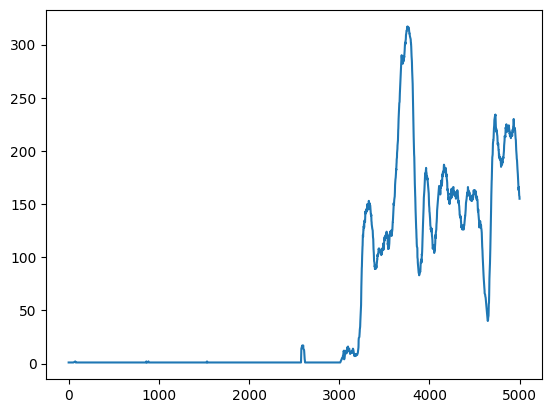

In [8]:
n=1
plt.plot(time_df[n],nc_df[n])

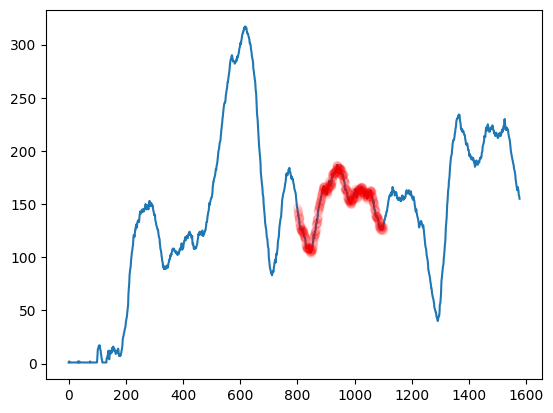

In [9]:
plt.plot(nc_df[n])
plt.plot(nc_df[n][800:1100],'ro',alpha=0.1)

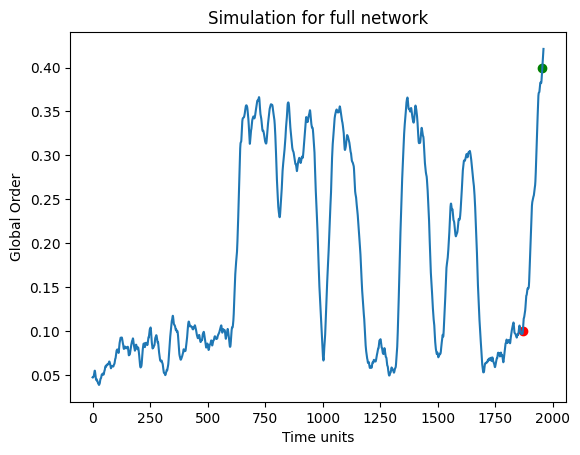

In [10]:
analyse.plot_global_synchrony(df_itr[itr_list[n]],0.05)

In [13]:
nc_df[n][800:1000].median().round()

156.0

## Finding mean node count for every transition

In [20]:
n=0
mean_count=[]
while n<len(itr_list):
    mean_count.append(nc_df[n][800:1000].median().round())
    n+=1
import statistics
coverage=statistics.median(mean_count)
    
    

In [21]:
coverage

302.0

In [22]:
mean_count

[288.0,
 156.0,
 311.0,
 337.0,
 319.0,
 186.0,
 288.0,
 320.0,
 302.0,
 272.0,
 322.0,
 278.0,
 258.0,
 326.0,
 314.0,
 260.0,
 186.0,
 230.0,
 317.0,
 238.0,
 340.0,
 321.0,
 326.0,
 344.0,
 320.0,
 301.0,
 232.0,
 321.0,
 308.0,
 142.0,
 305.0,
 313.0,
 154.0,
 260.0,
 316.0,
 91.0,
 130.0,
 328.0,
 153.0,
 328.0,
 324.0,
 294.0,
 320.0,
 275.0,
 304.0,
 322.0,
 270.0,
 276.0,
 302.0,
 300.0,
 212.0,
 278.0,
 292.0,
 315.0,
 339.0,
 150.0,
 53.0,
 260.0,
 342.0,
 348.0,
 304.0,
 274.0,
 340.0,
 102.0,
 73.0,
 334.0,
 333.0,
 336.0,
 285.0,
 182.0,
 266.0,
 273.0,
 330.0,
 280.0,
 322.0,
 320.0,
 318.0,
 318.0]

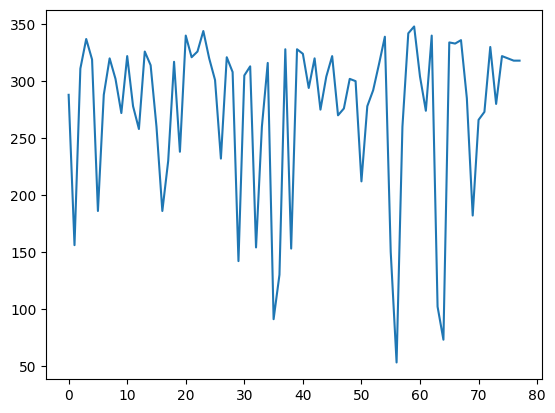

In [23]:
plt.plot(mean_count)

Using median as it takes care of outliers

In [50]:
# defining function for calculating coverage as shown above 
# import statistics module
# used medians through out

def compute_coverage(df_itr,df_nc): 
    param=analyse.compute_param(df_itr,0.05)
        
    # lst1 store iteration numbers which had transitions (single and multiple both)
    lst1=param['itr_tran']
    # lst2 stores iteration numbers which have fall back or multiple transitions 
    lst2=param['itr_st']
    # finding only those iterations which have only single transitions
    itr_list=set(lst1)-set(lst2)
    itr_list=list(itr_list)

    node_count_list=[]
    for i in itr_list:
        l=analyse.node_count(df_nc.loc[i])
        node_count_list.append(l['node_count'])

    nc_df=pd.DataFrame(node_count_list).T

    n=0
    mean_count=[]
    while n<len(itr_list):
        mean_count.append(nc_df[n][800:1000].median().round())
        n+=1
    
    coverage=statistics.median(mean_count).round()
    return coverage

    

In [29]:
compute_coverage(df_itr,df_nc)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


302.0

# Compute for all nodes

### Important nodes

Reading data from folders

In [61]:
FN_folder = Path('../../data/raw/FN/')
ENTI_folder = Path('../../data/raw/ENTI/')
ORBI_folder = Path('../../data/raw/ORBI/')
PERI_folder = Path('../../data/raw/PERI/')
PIR_folder = Path('../../data/raw/PIR/')
RE_folder = Path('../../data/raw/RE/')
BLA_folder = Path('../../data/raw/BLA/')
files_nc=[]
files_itr=[]
folders=[FN_folder,ENTI_folder,ORBI_folder,PERI_folder,PIR_folder,RE_folder, BLA_folder]
for folder in folders:
    file_nc=glob.glob(str(folder / "nc_200.bz2"))
    files_nc.append(file_nc)
    file_itr=glob.glob(str(folder / "itr_200.bz2"))
    files_itr.append(file_itr)

print(files_nc)
print(files_itr)

[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]
[['../../data/raw/FN/itr_200.bz2'], ['../../data/raw/ENTI/itr_200.bz2'], ['../../data/raw/ORBI/itr_200.bz2'], ['../../data/raw/PERI/itr_200.bz2'], ['../../data/raw/PIR/itr_200.bz2'], ['../../data/raw/RE/itr_200.bz2'], ['../../data/raw/BLA/itr_200.bz2']]


In [62]:
# compute coverage for each important nodes
coverage=[]
for f_nc, f_itr in zip(files_nc, files_itr):
    # f_nc is the current item from files_nc
    # f_itr is the current item from files_itr
    df_nc = pd.read_pickle(f_nc[0], compression="bz2")
    df_itr = pd.read_pickle(f_itr[0], compression="bz2")
    coverage.append(analyse.compute_coverage(df_itr, df_nc))

print(coverage)
    

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
Number of transitions / 100 iteration [0, 38, 78]
Number of transition [3, 4, 6, 9, 15, 18, 22, 25, 26, 28, 29, 31, 33, 34, 35, 36, 41, 44, 51, 52, 60, 70, 75, 82, 86, 87, 88, 90, 91, 92, 96, 99, 101, 106, 109, 110, 112, 113, 114, 116, 117, 11

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Making dictionary for storing coverage

In [35]:
node=['FN','ENTI','ORBI','PERI','PIR','RE','BLA']
coverage_dict=dict(zip(node,coverage))
print(coverage_dict)

{'FN': 302.0, 'ENTI': 290.0, 'ORBI': 303.0, 'PERI': 312.5, 'PIR': 308.0, 'RE': 298.0, 'BLA': 296.0}


## Connector nodes

In [46]:
data_folder = Path('../../data/raw/check_connector/')
files_nc=glob.glob(str(data_folder / "nc_200*.bz2"))
files_itr=glob.glob(str(data_folder / "itr_200*.bz2"))
print(files_nc)
print(files_itr)

['../../data/raw/check_connector/nc_200_1.bz2', '../../data/raw/check_connector/nc_200_2.bz2', '../../data/raw/check_connector/nc_200_3.bz2', '../../data/raw/check_connector/nc_200_4.bz2', '../../data/raw/check_connector/nc_200_5.bz2']
['../../data/raw/check_connector/itr_200_1.bz2', '../../data/raw/check_connector/itr_200_2.bz2', '../../data/raw/check_connector/itr_200_3.bz2', '../../data/raw/check_connector/itr_200_4.bz2', '../../data/raw/check_connector/itr_200_5.bz2', '../../data/raw/check_connector/itr_200_fn.bz2']


In [51]:
coverage=[]
for f_nc, f_itr in zip(files_nc, files_itr):
    # f_nc is the current item from files_nc
    # f_itr is the current item from files_itr
    df_nc = pd.read_pickle(f_nc, compression="bz2")
    df_itr = pd.read_pickle(f_itr, compression="bz2")
    coverage.append(analyse.compute_coverage(df_itr, df_nc))

print(coverage)
    

Number of transitions / 100 iteration [1, 46, 91]
Number of transition [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 21, 25, 28, 30, 35, 39, 40, 41, 42, 45, 50, 51, 53, 55, 56, 58, 59, 62, 63, 68, 69, 70, 73, 74, 75, 78, 82, 89, 92, 97, 98, 103, 105, 107, 108, 111, 117, 120, 121, 122, 129, 132, 134, 135, 136, 137, 138, 142, 144, 148, 150, 152, 156, 158, 162, 165, 166, 167, 168, 170, 171, 173, 174, 176, 179, 180, 183, 186, 187, 188, 190, 191, 198, 199]
Number of transition with more than one transition or a fall back [14, 16, 19, 28, 42, 63, 75, 92, 98, 107, 120, 122, 144, 156, 179, 187, 190, 199]
Number of transitions / 100 iteration [0, 38, 78]
Number of transition [1, 5, 6, 10, 13, 15, 20, 25, 27, 30, 31, 34, 41, 43, 45, 48, 51, 53, 55, 56, 61, 65, 66, 69, 70, 71, 77, 85, 86, 88, 91, 92, 93, 102, 104, 110, 116, 119, 122, 123, 126, 127, 128, 130, 132, 137, 141, 151, 159, 160, 162, 163, 169, 174, 178, 181, 182, 185, 186, 189, 190, 193, 196, 197, 199]
Number of transition with more than one transi

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Number of transitions / 100 iteration [0, 29, 65]
Number of transition [1, 2, 5, 7, 8, 9, 12, 15, 21, 23, 25, 30, 31, 34, 45, 46, 47, 48, 55, 59, 69, 77, 79, 80, 82, 83, 96, 97, 102, 116, 120, 121, 122, 124, 125, 127, 129, 135, 143, 144, 145, 146, 149, 151, 155, 156, 164, 167, 169, 170, 171, 172, 174, 177, 183, 184, 186, 188]
Number of transition with more than one transition or a fall back [7, 21, 23, 25, 30, 45, 69, 79, 82, 125, 127, 146, 149, 169, 170, 183, 186]
[294.0, 288.0, 312.0, 298.0, 305.0]


In [52]:
label=['214,1','215,2','249,36','137,350','53,266']
conn_dict=dict(zip(label,coverage))
print(conn_dict)

{'214,1': 294.0, '215,2': 288.0, '249,36': 312.0, '137,350': 298.0, '53,266': 305.0}


# Control Nodes

In [53]:
data_folder = Path('../../data/raw/check_control/')
files_nc=glob.glob(str(data_folder / "nc_200*.bz2"))
files_itr=glob.glob(str(data_folder / "itr_200*.bz2"))
print(files_nc)
print(files_itr)

['../../data/raw/check_control/nc_200_1.bz2', '../../data/raw/check_control/nc_200_2.bz2', '../../data/raw/check_control/nc_200_3.bz2', '../../data/raw/check_control/nc_200_4.bz2']
['../../data/raw/check_control/itr_200_1.bz2', '../../data/raw/check_control/itr_200_2.bz2', '../../data/raw/check_control/itr_200_3.bz2', '../../data/raw/check_control/itr_200_4.bz2', '../../data/raw/check_control/itr_200_fn.bz2']


In [55]:
coverage=[]
for f_nc, f_itr in zip(files_nc, files_itr):
    # f_nc is the current item from files_nc
    # f_itr is the current item from files_itr
    df_nc = pd.read_pickle(f_nc, compression="bz2")
    df_itr = pd.read_pickle(f_itr, compression="bz2")
    coverage.append(analyse.compute_coverage(df_itr, df_nc))

print(coverage)

Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28, 29, 38, 39, 40, 42, 44, 48, 51, 52, 53, 58, 60, 62, 67, 69, 73, 74, 78, 79, 81, 84, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 107, 109, 111, 113, 115, 116, 123, 124, 125, 127, 130, 131, 132, 133, 136, 137, 139, 140, 142, 145, 148, 149, 159, 160, 161, 165, 166, 169, 177, 178, 181, 182, 183, 185, 187, 189, 190, 191, 192, 194, 196, 198, 199]
Number of transition with more than one transition or a fall back [0, 12, 21, 29, 39, 40, 42, 44, 53, 74, 78, 79, 91, 103, 116, 124, 133, 136, 137, 140, 149, 159, 160, 161, 166, 177, 178, 181, 198]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Number of transitions / 100 iteration [1, 78, 132]
Number of transition [0, 1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 23, 24, 25, 27, 28, 29, 30, 32, 37, 39, 40, 41, 43, 44, 45, 46, 47, 50, 51, 53, 54, 56, 58, 59, 60, 61, 62, 64, 66, 67, 69, 70, 72, 73, 74, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 107, 109, 112, 115, 117, 119, 123, 124, 127, 132, 134, 136, 140, 141, 142, 143, 144, 151, 152, 153, 154, 155, 156, 161, 168, 169, 171, 173, 177, 181, 184, 185, 187, 188, 192, 193, 194, 195, 196, 197, 199]
Number of transition with more than one transition or a fall back [9, 10, 13, 29, 37, 39, 43, 45, 46, 50, 61, 69, 73, 80, 81, 86, 89, 102, 103, 112, 117, 123, 124, 132, 136, 140, 141, 153, 168, 171, 173, 185, 196]
Number of transitions / 100 iteration [1, 46, 91]
Number of transition [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 21, 25, 28, 30, 35, 39, 40, 41, 42, 45, 50, 51, 53, 55, 56, 58, 59, 62, 63, 68, 69, 70, 73, 74, 75, 78, 82, 89,

In [57]:
label=['251,38'
,'71,284',
'1, 214'
,'149, 362']
control_dict=dict(zip(label,coverage))
print(control_dict)

{'251,38': 306.0, '71,284': 304.0, '1, 214': 294.0, '149, 362': 293.0}
